<a href="https://colab.research.google.com/github/parnikp24/Nuero_Research_Project.ipynb/blob/main/Neuro_Research_Project_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install nilearn

In [14]:
from nilearn import datasets
haxby_dataset = datasets.fetch_haxby()
print("Data downloaded!")

[fetch_haxby] Dataset directory found: /root/nilearn_data/haxby2001

Data downloaded!


In [15]:
print(haxby_dataset.description)

.. _haxby_dataset:

Haxby dataset

Access
------
See :func:`nilearn.datasets.fetch_haxby`.

Notes
-----
Results from a classical :term:`fMRI` study that investigated the differences between
the neural correlates of face versus object processing in the ventral visual
stream. Face and object stimuli showed widely distributed and overlapping
response patterns.

See :footcite:t:`Haxby2001`.

Content
-------
The "simple" dataset includes:
    :'func': Nifti images with bold data
    :'session_target': Text file containing run data
    :'mask': Nifti images with employed mask
    :'session': Text file with condition labels

The full dataset additionally includes
    :'anat': Nifti images with anatomical image
    :'func': Nifti images with bold data
    :'mask_vt': Nifti images with mask for ventral visual/temporal cortex
    :'mask_face': Nifti images with face-reponsive brain regions
    :'mask_house': Nifti images with house-reponsive brain regions
    :'mask_face_little': Spatially more 

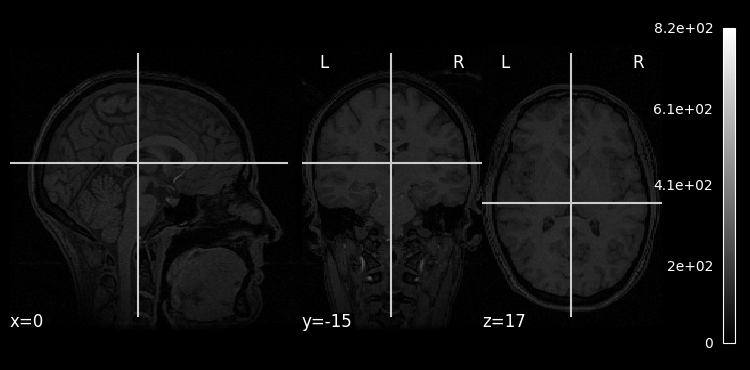

In [16]:
from nilearn import plotting
display = plotting.plot_anat(haxby_dataset.anat[0])
display.savefig('brain_image.png')

In [17]:
import pandas as pd
labels = pd.read_csv(haxby_dataset.session_target[0], sep=" ")
print(labels['labels'].unique())
print(labels.columns)

<ArrowStringArray>
[        'rest',     'scissors',         'face',          'cat',
         'shoe',        'house', 'scrambledpix',       'bottle',
        'chair']
Length: 9, dtype: str
Index(['labels', 'chunks'], dtype='str')


In [18]:
condition_mask = labels['labels'].isin(['face', 'house'])
y = labels['labels'][condition_mask]
print(y.value_counts())

labels
face     108
house    108
Name: count, dtype: int64


In [19]:
from nilearn.image import index_img
func_filename = haxby_dataset.func[0]
fmri_niimgs = index_img(func_filename, condition_mask)
print(fmri_niimgs.shape)

(40, 64, 64, 216)


In [20]:
from nilearn.decoding import Decoder
from sklearn.model_selection import KFold
import numpy as np

mask_filename = haxby_dataset.mask_vt[0]
cv = KFold(n_splits=5)
decoder = Decoder(estimator='svc', mask=mask_filename, standardize=True, cv=cv)
decoder.fit(fmri_niimgs, y)
print("Cross-validated accuracy per fold:", decoder.cv_scores_['face'])
mean_accuracy = np.mean(decoder.cv_scores_['face'])
print(f"Mean cross-validated accuracy: {mean_accuracy * 100:.2f}%")

/tmp/ipykernel_3005/3539645308.py:8: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  decoder.fit(fmri_niimgs, y)


Cross-validated accuracy per fold: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Mean cross-validated accuracy: 100.00%


/tmp/ipykernel_3005/3539645308.py:8: UserWarning: screening_percentile set to '100' despite requesting 'screening_percentile=20'. 
All elements in the mask will be included. 
This usually occurs when the mask image is too small compared to full brain mask.
  decoder.fit(fmri_niimgs, y)


### Correcting a Methodological Error: Data Leakage

My first attempt used random K-Fold cross-validation, which produced an
unrealistic 100% accuracy on every fold. This happened because fMRI scans
taken close together in time are naturally similar to each other, so
randomly splitting the data let information "leak" between the training
and testing sets — the model wasn't really being tested on new data.

To fix this, I switched to Leave-One-Group-Out cross-validation, splitting
by scan session (the `chunks` variable in the dataset) instead of randomly.
This ensures the model is always tested on a completely separate scanning
session it has never seen during training, giving an honest, unbiased
accuracy measurement.

In [21]:
from sklearn.model_selection import LeaveOneGroupOut

groups = labels['chunks'][condition_mask]
logo = LeaveOneGroupOut()
decoder = Decoder(estimator='svc', mask=mask_filename, standardize=True, cv=logo)
decoder.fit(fmri_niimgs, y, groups=groups)
print("Accuracy per run:", decoder.cv_scores_['face'])
mean_accuracy = np.mean(decoder.cv_scores_['face'])
print(f"Mean Leave-One-Run-Out accuracy: {mean_accuracy * 100:.2f}%")

/tmp/ipykernel_3005/3561324074.py:6: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  decoder.fit(fmri_niimgs, y, groups=groups)
/tmp/ipykernel_3005/3561324074.py:6: UserWarning: screening_percentile set to '100' despite requesting 'screening_percentile=20'. 
All elements in the mask will be included. 
This usually occurs when the mask image is too small compared to full brain mask.
  decoder.fit(fmri_niimgs, y, groups=groups)


Accuracy per run: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Mean Leave-One-Run-Out accuracy: 100.00%


In [22]:
condition_mask2 = labels['labels'].isin(['face', 'cat'])
y2 = labels['labels'][condition_mask2]
groups2 = labels['chunks'][condition_mask2]
fmri_niimgs2 = index_img(func_filename, condition_mask2)

decoder2 = Decoder(estimator='svc', mask=mask_filename, standardize=True, cv=LeaveOneGroupOut())
decoder2.fit(fmri_niimgs2, y2, groups=groups2)
print("Face vs Cat accuracy:", np.mean(decoder2.cv_scores_['face']) * 100, "%")

/tmp/ipykernel_3005/2066903444.py:7: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  decoder2.fit(fmri_niimgs2, y2, groups=groups2)
/tmp/ipykernel_3005/2066903444.py:7: UserWarning: screening_percentile set to '100' despite requesting 'screening_percentile=20'. 
All elements in the mask will be included. 
This usually occurs when the mask image is too small compared to full brain mask.
  decoder2.fit(fmri_niimgs2, y2, groups=groups2)


Face vs Cat accuracy: 81.68724279835389 %


In [23]:
condition_mask3 = labels['labels'].isin(['house', 'chair'])
y3 = labels['labels'][condition_mask3]
groups3 = labels['chunks'][condition_mask3]
fmri_niimgs3 = index_img(func_filename, condition_mask3)

decoder3 = Decoder(estimator='svc', mask=mask_filename, standardize=True, cv=LeaveOneGroupOut())
decoder3.fit(fmri_niimgs3, y3, groups=groups3)
print("House vs Chair accuracy:", np.mean(decoder3.cv_scores_['house']) * 100, "%")

/tmp/ipykernel_3005/239227456.py:7: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  decoder3.fit(fmri_niimgs3, y3, groups=groups3)
/tmp/ipykernel_3005/239227456.py:7: UserWarning: screening_percentile set to '100' despite requesting 'screening_percentile=20'. 
All elements in the mask will be included. 
This usually occurs when the mask image is too small compared to full brain mask.
  decoder3.fit(fmri_niimgs3, y3, groups=groups3)


House vs Chair accuracy: 99.07407407407408 %


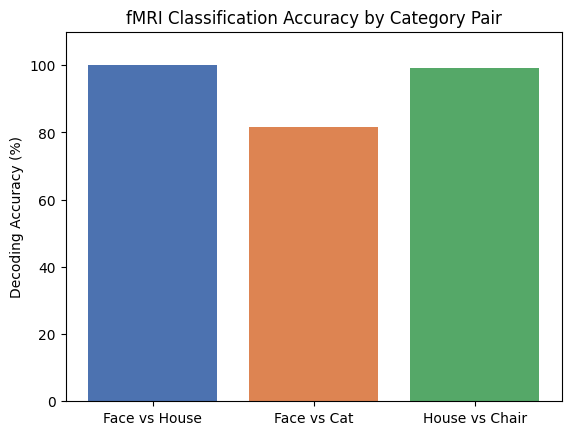

In [24]:
import matplotlib.pyplot as plt

comparisons = ['Face vs House', 'Face vs Cat', 'House vs Chair']
accuracies = [100.0, 81.69, 99.07]

plt.bar(comparisons, accuracies, color=['#4C72B0', '#DD8452', '#55A868'])
plt.ylabel('Decoding Accuracy (%)')
plt.title('fMRI Classification Accuracy by Category Pair')
plt.ylim(0, 110)
plt.savefig('accuracy_comparison.png')
plt.show()